# Лабораторная работа №1: Разведочный анализ и визуализация данных
**Дисциплина:** Технологии машинного обучения
**Датасет:** Backblaze Hard Drive Test Data (2016 Q1-Q2)
**Студент:** Яншин Т.И.
**Группа:** ИУ5-66Б

## 1. Описание выбранного набора данных
Источник: Kaggle, набор Backblaze hard drive test data (2016 Q1-Q2). Каждая строка - дневной снимок состояния диска с базовой информацией (модель, емкость, отказ) и S.M.A.R.T. показателями.
Локальный файл: D:/6 сем/тмо/dataset/harddrive.csv.

## 2. Постановка задачи
В рамках лабораторной работы необходимо:
1. Выполнить разведочный анализ выбранного датасета.
2. Рассчитать основные характеристики признаков.
3. Построить базовые графики для визуального исследования.
4. Оценить корреляции между числовыми признаками.
5. Подготовить артефакты отчета (таблицы и изображения).

In [ ]:
# 2. Импорт библиотек и настройка окружения
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
sns.set_theme(style='whitegrid')
%matplotlib inline
plt.rcParams['figure.figsize'] = (12,6)
Path('figures').mkdir(exist_ok=True)

In [ ]:
# 3. Загрузка датасета
data_path = Path(r'D:/6 сем/тмо/dataset/harddrive.csv')
if not data_path.exists():
    raise FileNotFoundError(f'Файл не найден: {data_path}')

df = pd.read_csv(data_path, low_memory=False)
print('shape =', df.shape)
display(df.head())
print('Память (MB):', round(df.memory_usage(deep=True).sum() / (1024**2), 2))
print('Количество строк:', len(df))

shape = (3179295, 95)


,date,serial_number,model,capacity_bytes,failure,smart_1_normalized,smart_1_raw,smart_2_normalized,smart_2_raw,smart_3_normalized,...,smart_250_normalized,smart_250_raw,smart_251_normalized,smart_251_raw,smart_252_normalized,smart_252_raw,smart_254_normalized,smart_254_raw,smart_255_normalized,smart_255_raw
0,2016-01-01,MJ0351YNG9Z0XA,Hitachi HDS5C3030ALA630,1.482490e-311,0,100,0,135.0,108.0,143,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-01-01,Z305B2QN,ST4000DM000,1.976651e-311,0,113,54551400,NaN,NaN,96,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-01-01,MJ0351YNG9Z7LA,Hitachi HDS5C3030ALA630,1.482490e-311,0,100,0,136.0,104.0,124,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-01-01,MJ0351YNGABYAA,Hitachi HDS5C3030ALA630,1.482490e-311,0,100,0,136.0,104.0,137,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-01-01,WD-WMC4N2899475,WDC WD30EFRX,1.482490e-311,0,200,0,NaN,NaN,175,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Память (MB): 2785.7
Количество строк: 3179295


In [ ]:
# 4. Структура, dtypes, базовые характеристики
display(df.dtypes.value_counts())
print('Всего столбцов:', len(df.columns))
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
print('Числовых:', len(num_cols), 'Категориальных:', len(cat_cols))
display(df.columns[:100])

float64    70
int64      22
object      3
Name: count, dtype: int64

Всего столбцов: 95
Числовых: 92 Категориальных: 3


Index(['date', 'serial_number', 'model', 'capacity_bytes', 'failure',
       'smart_1_normalized', 'smart_1_raw', 'smart_2_normalized',
       'smart_2_raw', 'smart_3_normalized', 'smart_3_raw',
       'smart_4_normalized', 'smart_4_raw', 'smart_5_normalized',
       'smart_5_raw', 'smart_7_normalized', 'smart_7_raw',
       'smart_8_normalized', 'smart_8_raw', 'smart_9_normalized',
       'smart_9_raw', 'smart_10_normalized', 'smart_10_raw',
       'smart_11_normalized', 'smart_11_raw', 'smart_12_normalized',
       'smart_12_raw', 'smart_13_normalized', 'smart_13_raw',
       'smart_15_normalized', 'smart_15_raw', 'smart_22_normalized',
       'smart_22_raw', 'smart_183_normalized', 'smart_183_raw',
       'smart_184_normalized', 'smart_184_raw', 'smart_187_normalized',
       'smart_187_raw', 'smart_188_normalized', 'smart_188_raw',
       'smart_189_normalized', 'smart_189_raw', 'smart_190_normalized',
       'smart_190_raw', 'smart_191_normalized', 'smart_191_raw',
       'smart_1

In [ ]:
# 5. Пропуски и приведение типов
miss = df.isnull().sum().sort_values(ascending=False)
display(miss[miss > 0].head(50))
display(((miss / len(df)) * 100)[miss > 0].head(50).rename('% missing'))

# попытка преобразовать дату, если есть столбец date
date_cols = [c for c in df.columns if 'date' in c.lower()]
for c in date_cols:
    try:
        df[c] = pd.to_datetime(df[c], errors='coerce')
        print('Converted', c)
    except Exception as e:
        print('Skip convert', c, e)

# привести очевидные id-колонки к category
for c in ['model', 'serial_number', 'serial', 'manufacturer']:
    if c in df.columns:
        df[c] = df[c].astype('category')

# рабочий набор числовых признаков: исключаем столбцы с >60% пропусков
missing_ratio = (df[num_cols].isna().mean()).sort_values(ascending=False)
analysis_cols = missing_ratio[missing_ratio <= 0.60].index.tolist()
print('Числовых признаков всего:', len(num_cols))
print('Оставлено для анализа:', len(analysis_cols))

smart_15_raw            3179295
smart_15_normalized     3179295
smart_255_raw           3179295
smart_255_normalized    3179295
smart_201_normalized    3179289
smart_13_normalized     3179289
smart_13_raw            3179289
smart_201_raw           3179289
smart_22_normalized     3176955
smart_22_raw            3176955
smart_250_normalized    3176460
smart_250_raw           3176460
smart_252_normalized    3176460
smart_251_normalized    3176460
smart_251_raw           3176460
smart_252_raw           3176460
smart_254_raw           3171360
smart_254_normalized    3171360
smart_222_raw           3169385
smart_222_normalized    3169385
smart_224_normalized    3169385
smart_220_raw           3169385
smart_220_normalized    3169385
smart_224_raw           3169385
smart_226_normalized    3169385
smart_226_raw           3169385
smart_225_raw           3146200
smart_225_normalized    3146200
smart_223_normalized    3136290
smart_223_raw           3136290
smart_11_normalized     3032481
smart_20

smart_15_raw            100.000000
smart_15_normalized     100.000000
smart_255_raw           100.000000
smart_255_normalized    100.000000
smart_201_normalized     99.999811
smart_13_normalized      99.999811
smart_13_raw             99.999811
smart_201_raw            99.999811
smart_22_normalized      99.926399
smart_22_raw             99.926399
smart_250_normalized     99.910829
smart_250_raw            99.910829
smart_252_normalized     99.910829
smart_251_normalized     99.910829
smart_251_raw            99.910829
smart_252_raw            99.910829
smart_254_raw            99.750416
smart_254_normalized     99.750416
smart_222_raw            99.688296
smart_222_normalized     99.688296
smart_224_normalized     99.688296
smart_220_raw            99.688296
smart_220_normalized     99.688296
smart_224_raw            99.688296
smart_226_normalized     99.688296
smart_226_raw            99.688296
smart_225_raw            98.959046
smart_225_normalized     98.959046
smart_223_normalized

Converted date
Числовых признаков всего: 92
Оставлено для анализа: 52


In [ ]:
# 6. Расширенная описательная статистика (skew, kurtosis)
desc = df[analysis_cols].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T
desc['skew'] = df[analysis_cols].skew()
desc['kurtosis'] = df[analysis_cols].kurtosis()
display(desc.head(50))
desc.to_csv('lab1_descriptive_stats_extended.csv')
print('Saved lab1_descriptive_stats_extended.csv')

,count,mean,std,min,1%,25%,50%,75%,99%,max,skew,kurtosis
smart_196_normalized,1372837.0,1.118915e+02,3.530015e+01,1.000000e+00,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,2.520000e+02,2.520000e+02,2.755045,6.219976
smart_196_raw,1372837.0,1.872857e+00,3.703745e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.000000e+00,3.043000e+03,33.264127,1390.180671
smart_183_raw,1799457.0,4.461218e+00,3.293027e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,4.161400e+04,108.798152,12651.412641
smart_183_normalized,1799457.0,9.970454e+01,3.744400e+00,1.000000e+00,9.800000e+01,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,-24.090277,608.407041
smart_242_normalized,1803634.0,1.000739e+02,2.716549e+00,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,2.000000e+02,36.757075,1349.084062
smart_241_normalized,1803634.0,1.000739e+02,2.716549e+00,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,2.000000e+02,36.757075,1349.084062
smart_189_raw,1806458.0,1.423065e+01,7.488966e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,2.700000e+01,6.553500e+04,81.128450,6921.422266
smart_189_normalized,1806458.0,9.753200e+01,6.769637e+00,1.000000e+00,7.300000e+01,9.800000e+01,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,-7.135088,79.444233
smart_187_normalized,1806516.0,9.996584e+01,7.428963e-01,1.000000e+00,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,-43.166665,2933.797432
smart_184_normalized,1806516.0,9.999511e+01,1.650107e-01,9.400000e+01,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,-35.651822,1286.174108


Saved lab1_descriptive_stats_extended.csv


## Описание SMART-показателей

Ниже приведены общепринятые интерпретации SMART-атрибутов, которые используются в анализе (столбцы вида `smart_X_raw`). Конкретные значения могут немного отличаться у разных производителей, но в рамках лабораторной работы они рассматриваются как числовые индикаторы состояния диска.

- **`smart_1_raw` — Raw Read Error Rate**: показатель частоты/счётчика ошибок чтения с поверхности диска, которые потребовали коррекции средствами ECC. Рост значения обычно указывает на деградацию поверхности или проблемный канал чтения.
- **`smart_3_raw` — Spin-Up Time**: измерение времени раскрутки шпинделя до рабочей скорости после включения питания. Увеличение времени раскрутки может говорить о проблемах с механикой или питанием.
- **`smart_4_raw` — Start/Stop Count**: число циклов «старт/стоп» шпинделя (включение/выключение вращения). Характеризует количество механических циклов, которые пережил диск.
- **`smart_9_raw` — Power-On Hours**: суммарное количество часов наработки диска (включённого состояния). По сути, возраст диска в часах.
- **`smart_10_raw` — Spin Retry Count**: число повторных попыток раскрутки шпинделя до номинальной скорости. Ненулевые и растущие значения часто указывают на начинающиеся механические проблемы.
- **`smart_183_raw` — Runtime Bad Block / SATA Downshift (вендор-специфичный)**: счётчик проблемных блоков или событий понижения скорости SATA-интерфейса во время работы (в зависимости от производителя). Используется как индикатор ошибок на уровне носителя/интерфейса.
- **`smart_187_raw` — Reported Uncorrectable Errors**: количество необратимых ошибок чтения/записи, о которых диск сообщил хост-системе. Напрямую отражает появление фатальных ошибок.
- **`smart_189_raw` — High Fly Writes**: счётчик записей при аномально высоком положении головки над поверхностью пластины. Рост показателя может предшествовать деградации поверхности или проблемам с калибровкой головок.
- **`smart_191_raw` — G-Sense Error Rate**: число зарегистрированных ударов/вибрационных событий, при которых датчики ускорения диска зафиксировали превышение допустимых порогов.
- **`smart_192_raw` — Power-Off Retract Count**: количество парковок головок при отключении питания (штатном и аварийном). Характеризует число циклов парковки.
- **`smart_193_raw` — Load/Unload Cycle Count**: число циклов загрузки/выгрузки головок (load/unload) из парковочной зоны. Большие значения означают интенсивное использование механики позиционирования.
- **`smart_195_raw` — Hardware ECC Recovered**: счётчик ошибок чтения, успешно исправленных аппаратным корректором ошибок (ECC). Сам по себе высокий уровень может быть нормой, но рост во времени может сигнализировать о деградации поверхности.
- **`smart_199_raw` — UltraDMA CRC Error Count**: количество ошибок контрольной суммы (CRC) при передаче данных по интерфейсу SATA/UltraDMA. Часто связано с проблемами кабеля/разъёма, а не с самим накопителем.
- **`smart_200_raw` — Multi-Zone Error Rate / Write Error Rate (вендор-специфичный)**: показатель уровня ошибок при операциях записи/чтения в разных зонах диска. Рост значения может означать ухудшение надёжности записи.
- **`smart_225_raw` — Host Writes / Load/Unload / др. (вендор-специфичный)**: в зависимости от модели диска может отражать объём записанных данных хостом или дополнительный счётчик циклов загрузки/выгрузки. В анализе используется как числовой показатель нагрузки/износа.
- **`smart_250_raw` — Read Error Retry Rate (вендор-специфичный)**: показатель количества повторных попыток чтения после ошибок. Повышенные значения могут говорить о проблемах с поверхностью или головками.
- **`smart_251_raw` и `smart_252_raw` — вендор-специфичные атрибуты**: дополнительные счётчики, интерпретация которых зависит от производителя (часто связаны с температурой, ошибками записи/чтения или внутренней перенастройкой диска). В работе рассматриваются как анонимные числовые признаки, отражающие внутреннее состояние накопителя.


## 8. Визуальное исследование: распределения признаков (hist, KDE)

**Описание графиков распределения SMART-показателей.**\n\nДалее для каждого признака из списка `top12` (`smart_1_raw`, `smart_193_raw`, `smart_191_raw`, `smart_9_raw`, `smart_10_raw`, `smart_199_raw`, `smart_3_raw`, `smart_189_raw`, `smart_192_raw`, `smart_183_raw`, `smart_4_raw`, `smart_187_raw`) строится гистограмма с оценкой плотности (KDE). По оси X — числовое значение соответствующего SMART-атрибута, по оси Y — количество наблюдений; такой график позволяет увидеть форму распределения и наличие выбросов для каждого смарта.


Top features for plotting: ['smart_1_raw', 'smart_193_raw', 'smart_191_raw', 'smart_9_raw', 'smart_10_raw', 'smart_199_raw', 'smart_3_raw', 'smart_189_raw', 'smart_192_raw', 'smart_183_raw', 'smart_4_raw', 'smart_187_raw']


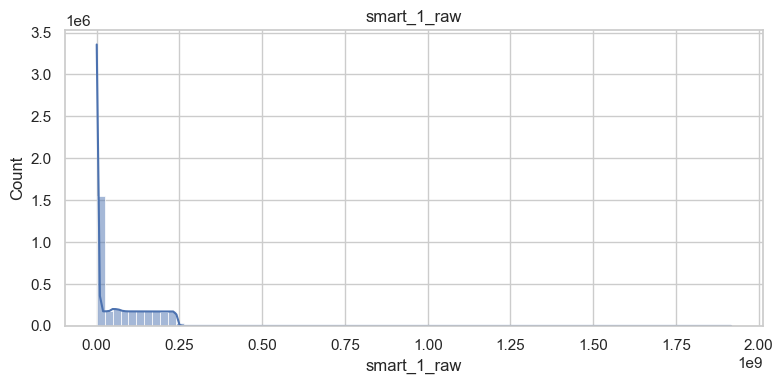

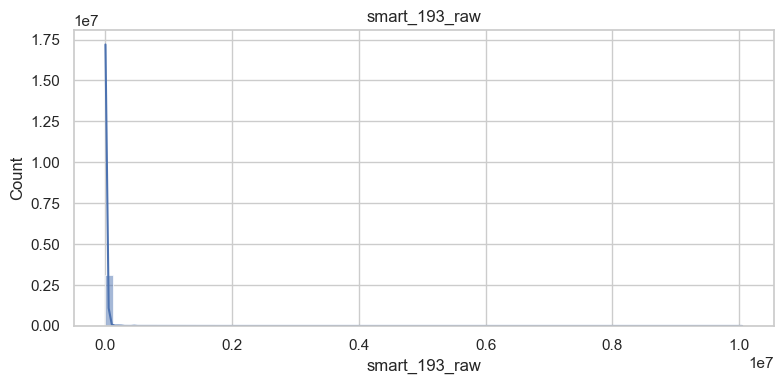

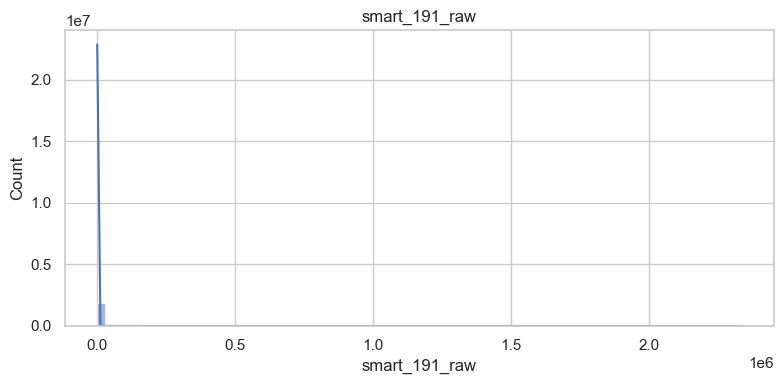

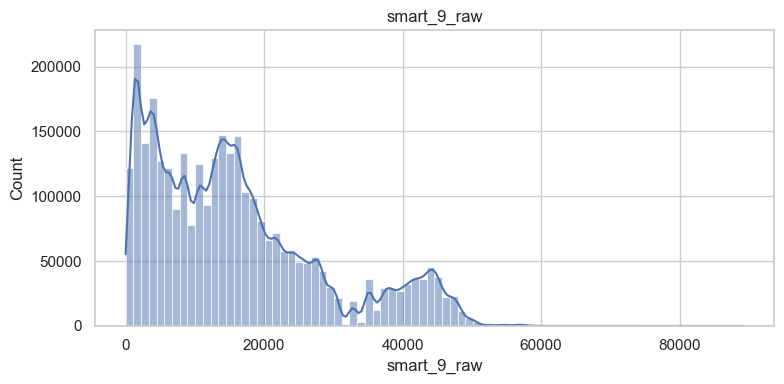

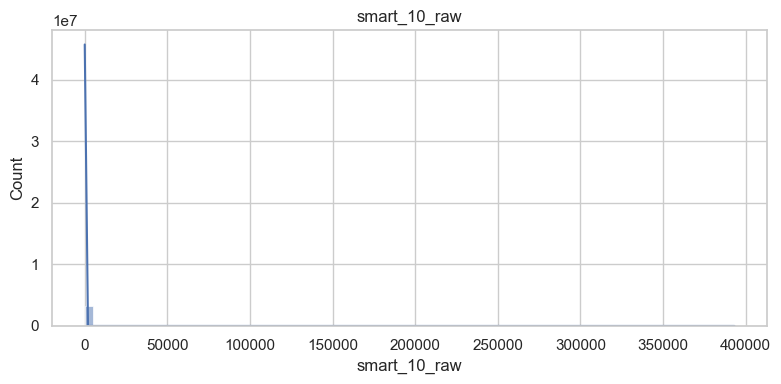

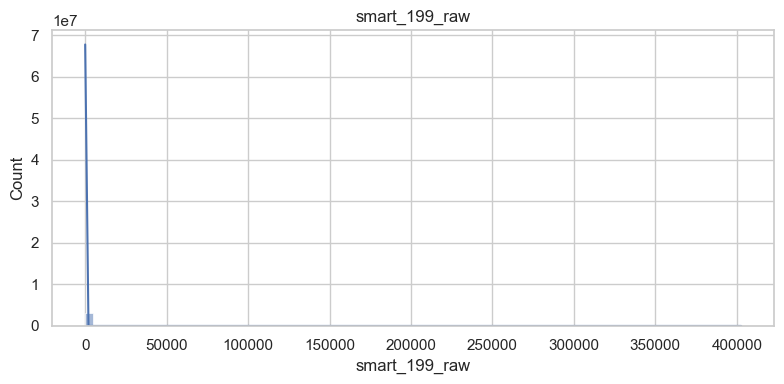

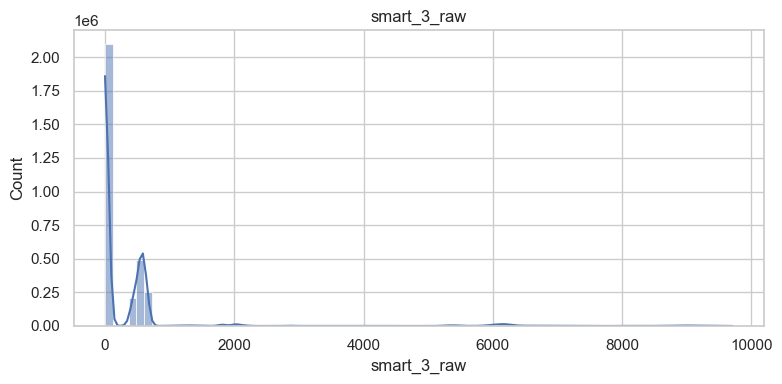

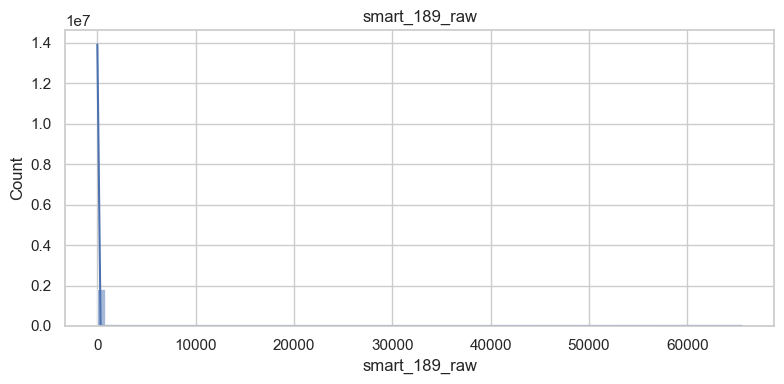

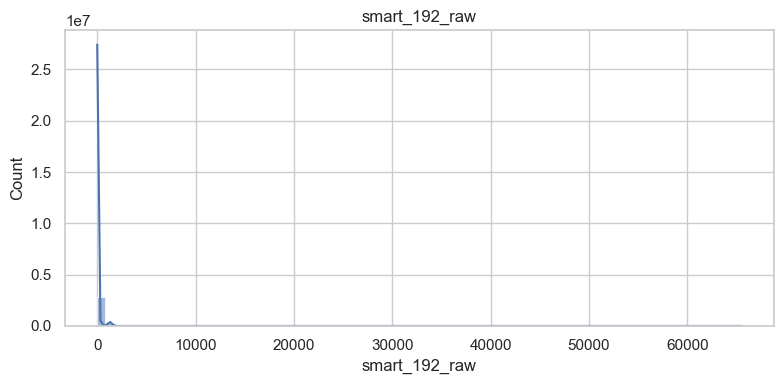

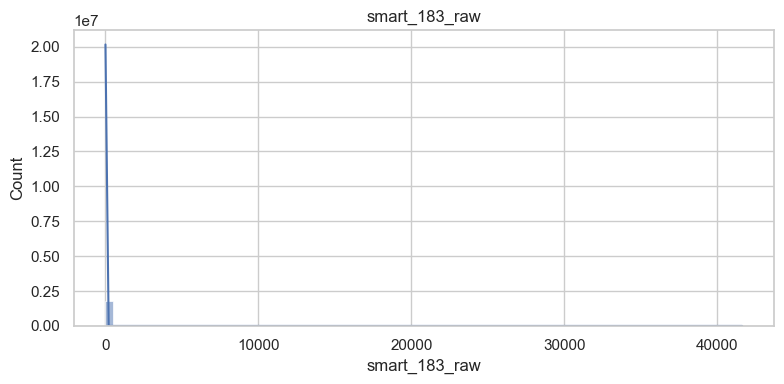

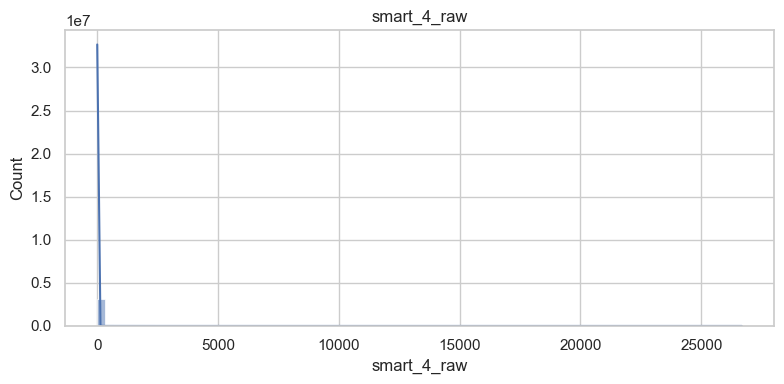

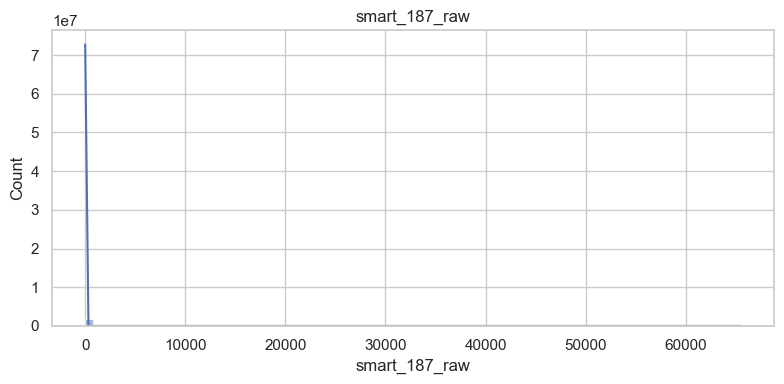

In [ ]:
# Выберем до 12 наиболее вариативных признаков
top12 = df[analysis_cols].var().sort_values(ascending=False).index[:12].tolist()
print('Top features for plotting:', top12)

for col in top12:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col].dropna(), bins=80, kde=True)
    plt.title(col)
    plt.tight_layout()
    plt.savefig(Path('figures') / f'hist_{col}.png', dpi=150)
    plt.show()

## 8. Boxplot и анализ по группам (если есть target)

**Описание boxplot по целевой переменной.**\n\nНиже для первых шести признаков из `top12` строятся boxplot-графики в разрезе целевой переменной `failure` (0 — диск работал, 1 — зафиксирован отказ). Каждый график показывает распределение значений выбранного SMART-показателя отдельно для исправных и отказавших дисков (медиана, межквартильный размах и выбросы), что позволяет визуально сравнить профили смартов для двух групп.


Target found: failure


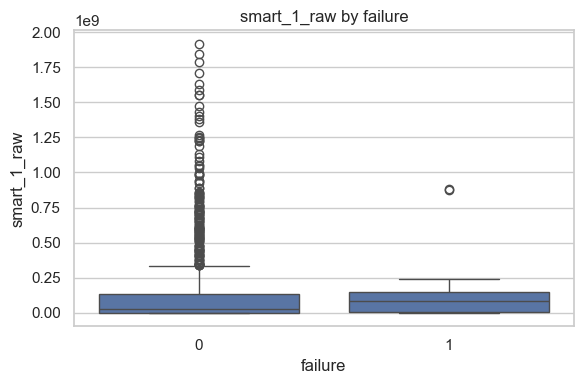

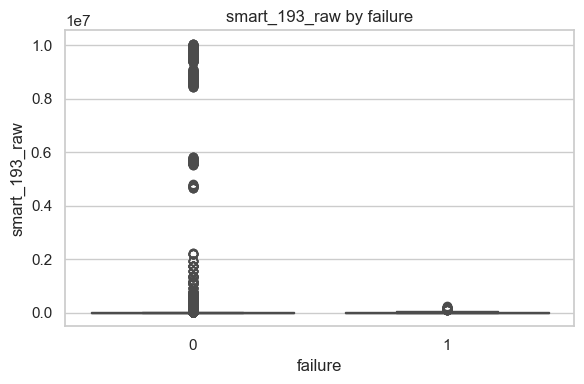

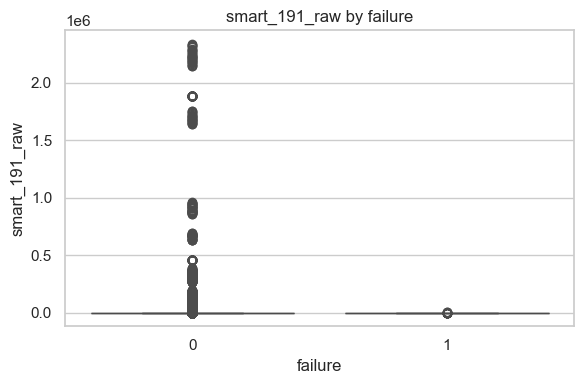

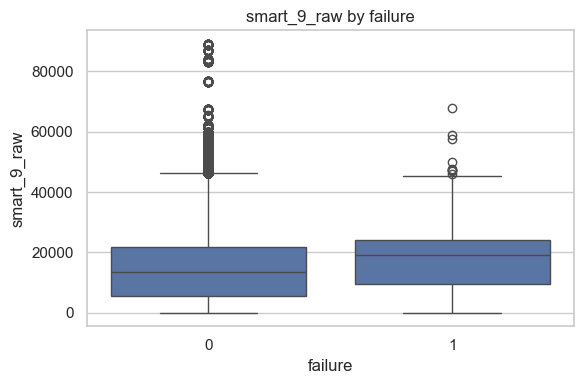

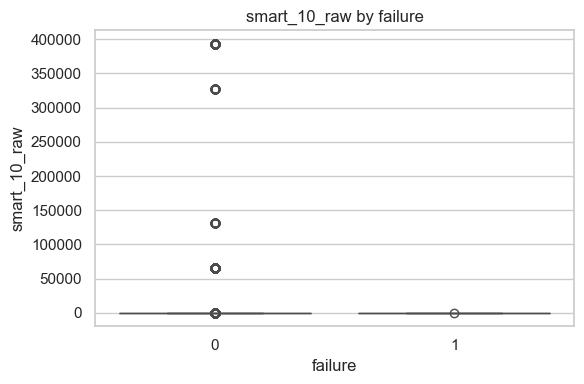

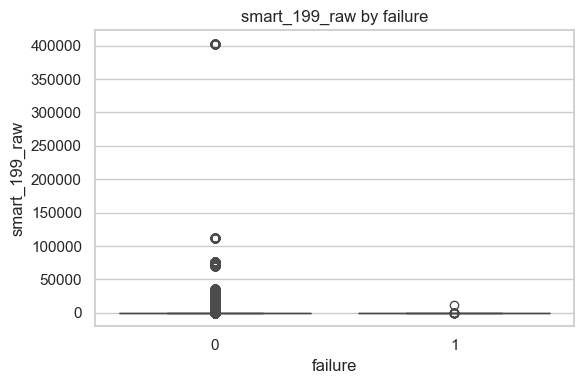

In [ ]:
# Попробуем обнаружить целевой столбец, содержащий информацию о сбое
targets = [c for c in df.columns if 'failure' in c.lower() or 'failed' in c.lower()]
targets
target = targets[0] if targets else None
print('Target found:', target)
if target is not None:
    for col in top12[:6]:
        plt.figure(figsize=(6,4))
        sns.boxplot(x=df[target].astype('category'), y=df[col])
        plt.title(f'{col} by {target}')
        plt.tight_layout()
        plt.savefig(Path('figures')/f'box_{col}_by_{target}.png', dpi=150)
        plt.show()
else:
    print('Target not found — skip grouped boxplots')

**Описание тепловой карты корреляций.**\n\nСледующий график — тепловая карта матрицы корреляций для подмножества числовых признаков. Цвет ячейки кодирует коэффициент линейной корреляции между парой признаков (красный/синий — сильная положительная/отрицательная связь, цвета около белого — слабая/отсутствующая связь). По ней можно увидеть группы сильно взаимосвязанных признаков и потенциальную мультиколлинеарность.


## 9. Корреляция признаков и тепловая карта

**Описание PCA-графика.**\n\nНиже приведён результат понижения размерности методом главных компонент (PCA) до двух измерений. Каждая точка на графике — отдельное наблюдение (состояние диска в конкретный день), оси `PC1` и `PC2` — линейные комбинации исходных признаков, объясняющие наибольшую долю дисперсии; по расположению точек можно судить о структуре данных (кластеры, вытянутые облака и т.п.).


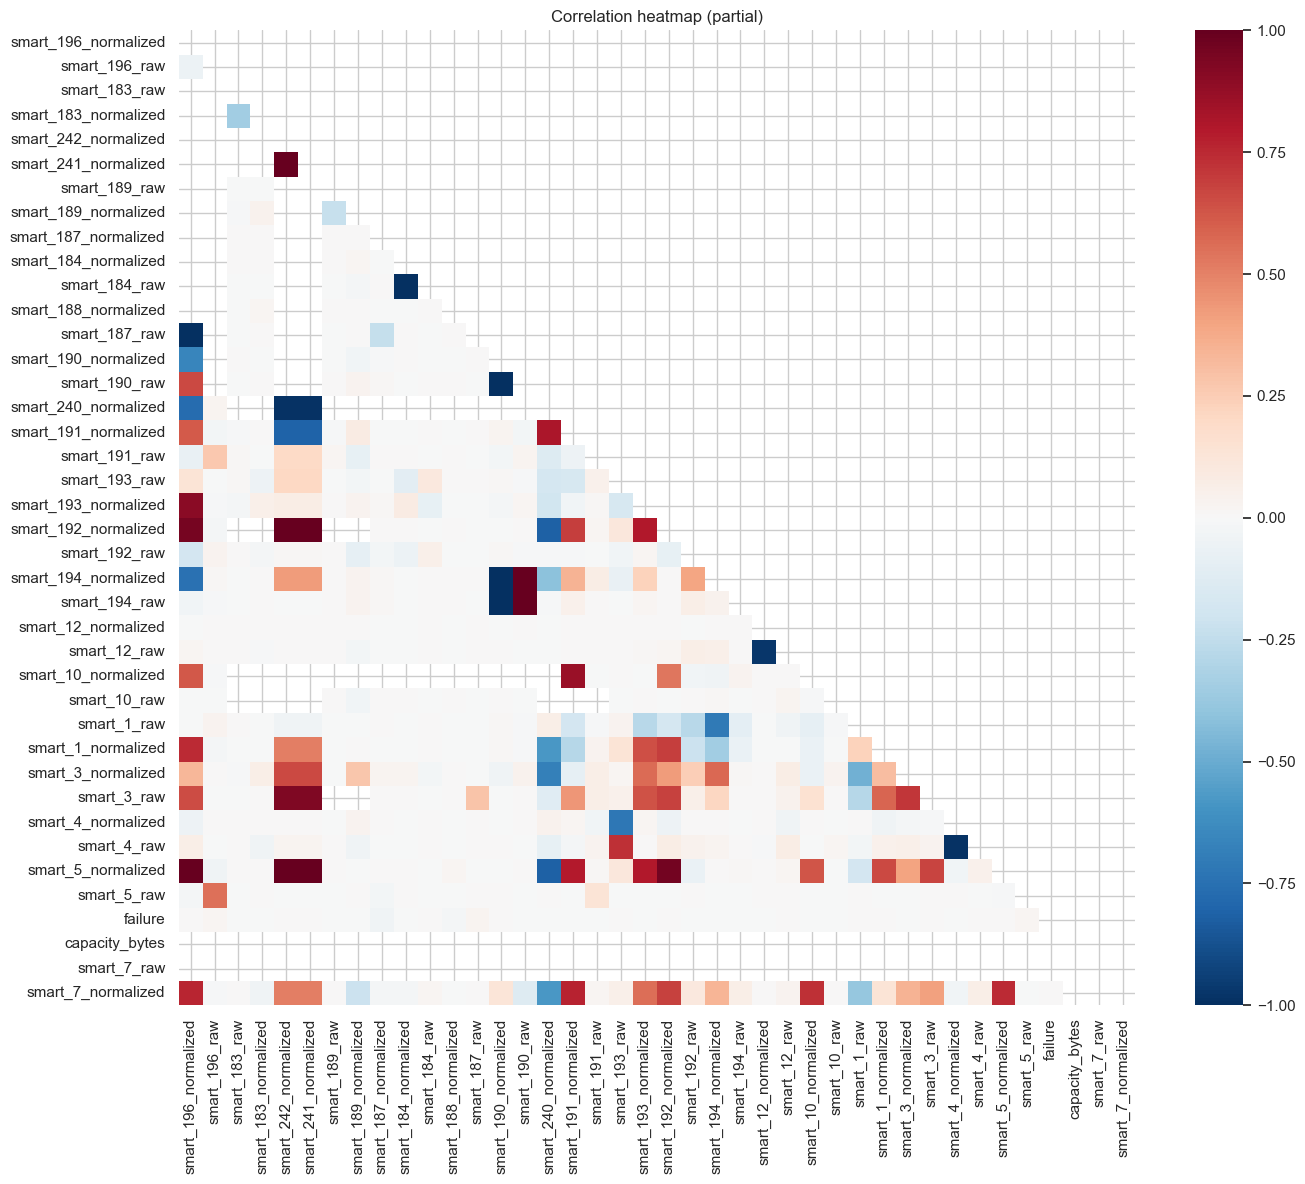

,f1,f2,corr
23,smart_190_normalized,smart_190_raw,-1.000000
12,smart_242_normalized,smart_192_normalized,1.000000
18,smart_241_normalized,smart_192_normalized,1.000000
27,smart_190_raw,smart_194_raw,1.000000
9,smart_242_normalized,smart_241_normalized,1.000000
25,smart_190_normalized,smart_194_raw,-1.000000
22,smart_184_normalized,smart_184_raw,-1.000000
0,smart_196_normalized,smart_187_raw,-1.000000
6,smart_196_normalized,smart_5_normalized,0.999854
21,smart_241_normalized,smart_197_normalized,0.999499


In [ ]:
corr = df[analysis_cols].corr()
corr.to_csv('lab1_correlation_matrix.csv')

cols = corr.columns[:40]
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr.loc[cols, cols], dtype=bool))
sns.heatmap(corr.loc[cols, cols], mask=mask, cmap='RdBu_r', center=0)
plt.title('Correlation heatmap (partial)')
plt.tight_layout()
plt.savefig(Path('figures') / 'corr_heatmap.png', dpi=150)
plt.show()

# сильные пары
strong = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        v = corr.iat[i, j]
        if abs(v) > 0.7:
            strong.append((corr.index[i], corr.columns[j], v))

strong_df = pd.DataFrame(strong, columns=['f1', 'f2', 'corr']).sort_values('corr', key=np.abs, ascending=False)
display(strong_df.head(20))

**Описание графика важностей признаков.**\n\nНиже отображается столбчатая диаграмма важностей признаков по модели `RandomForestClassifier`. По оси Y отложены имена признаков (в том числе SMART-показатели), по оси X — их относительная важность при предсказании целевой переменной `failure`; чем выше столбец, тем более значим признак для разделения исправных и отказавших дисков.


## 10. PCA (2 компоненты)

Explained variance ratio: [0.12961007 0.10744912]


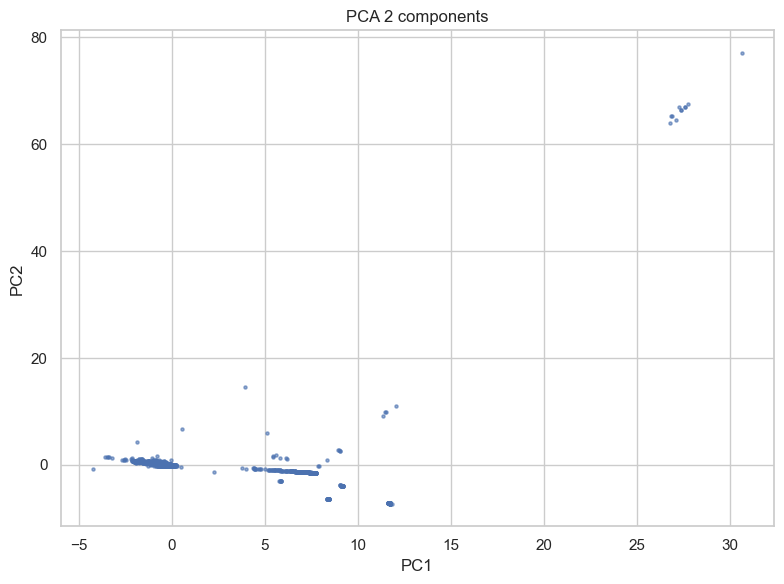

In [ ]:
# PCA на подвыборке с заполнением пропусков медианой
pca_cols = analysis_cols[: min(30, len(analysis_cols))]
X = df[pca_cols].copy()
X = X.fillna(X.median(numeric_only=True))

if len(X) > 1000:
    X = X.sample(min(20000, len(X)), random_state=1)

Xs = StandardScaler().fit_transform(X)
pca = PCA(n_components=2, random_state=1)
pc = pca.fit_transform(Xs)
print('Explained variance ratio:', pca.explained_variance_ratio_)

plt.figure(figsize=(8, 6))
plt.scatter(pc[:, 0], pc[:, 1], s=5, alpha=0.6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA 2 components')
plt.tight_layout()
plt.savefig(Path('figures') / 'pca.png', dpi=150)
plt.show()

## 11. Простая модель: RandomForest для оценки важностей признаков

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8999
           1       0.00      0.00      0.00         1

    accuracy                           1.00      9000
   macro avg       0.50      0.50      0.50      9000
weighted avg       1.00      1.00      1.00      9000



smart_192_raw           0.116068
smart_194_normalized    0.098663
smart_196_normalized    0.090832
smart_193_raw           0.087396
smart_12_raw            0.076040
smart_194_raw           0.069511
smart_4_raw             0.069124
smart_9_normalized      0.053408
smart_196_raw           0.051718
smart_5_normalized      0.048500
smart_3_normalized      0.043581
smart_1_raw             0.038769
smart_3_raw             0.034764
smart_1_normalized      0.032848
smart_193_normalized    0.032305
smart_5_raw             0.025467
smart_7_normalized      0.023672
smart_190_normalized    0.003333
smart_190_raw           0.001918
smart_192_normalized    0.000979
dtype: float64

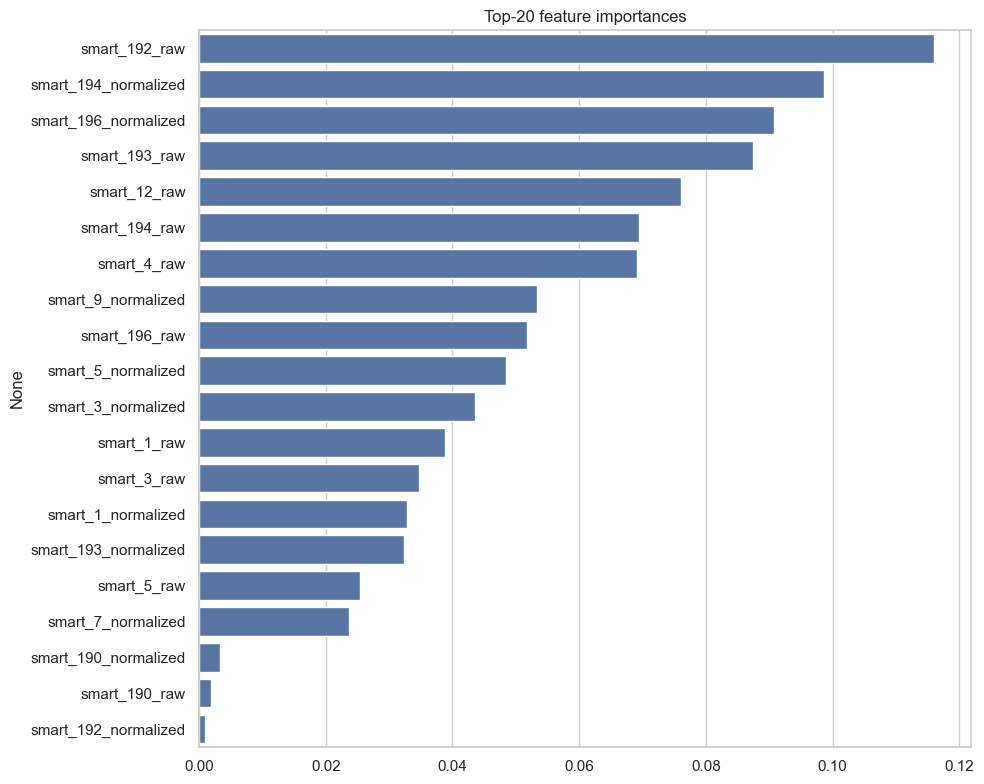

In [ ]:
if target is not None:
    model_cols = [c for c in analysis_cols if c != target][: min(40, max(1, len(analysis_cols) - 1))]
    data = df[model_cols + [target]].copy()
    data[model_cols] = data[model_cols].fillna(data[model_cols].median(numeric_only=True))
    data = data.dropna(subset=[target])

    try:
        y = data[target].astype(int)
    except Exception:
        y = pd.factorize(data[target])[0]

    X = data[model_cols]
    sample_n = min(30000, len(X))
    Xsamp = X.sample(sample_n, random_state=1)
    ysamp = y[Xsamp.index]

    X_train, X_test, y_train, y_test = train_test_split(
        Xsamp, ysamp, test_size=0.3, random_state=1, stratify=ysamp
    )
    clf = RandomForestClassifier(n_estimators=150, n_jobs=-1, random_state=1, class_weight='balanced')
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    print(classification_report(y_test, preds))

    importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
    display(importances.head(20))

    plt.figure(figsize=(10, 8))
    sns.barplot(x=importances.head(20).values, y=importances.head(20).index)
    plt.title('Top-20 feature importances')
    plt.tight_layout()
    plt.savefig(Path('figures') / 'feature_importances.png', dpi=150)
    plt.show()
else:
    print('Target not found - skip modelling')

## 13. Формирование отчетных материалов
Для отчета по методичке используются:
1. Титульная часть и описание задания (markdown-ячейки ноутбука).
2. Текст программы (code-ячейки ноутбука).
3. Экранные формы с результатами выполнения (outputs ячеек и сохраненные графики в папке figures).

Экспорт ноутбука в HTML:
- jupyter nbconvert --to html lab1_exploratory_analysis.ipynb

Публикация в GitHub-репозитории:
- git init
- git add .
- git commit -m "Lab1: EDA Backblaze"
- git remote add origin <your-repo-url>
- git push -u origin main

In [ ]:
# Проверка сформированных артефактов для отчета
artifacts = [
    'lab1_descriptive_stats_extended.csv',
    'lab1_correlation_matrix.csv',
    'figures/corr_heatmap.png',
    'figures/pca.png',
    'figures/feature_importances.png',
]

for p in artifacts:
    print(p, '->', Path(p).exists())

print('Всего изображений в figures:', len(list(Path('figures').glob('*.png'))))

lab1_descriptive_stats_extended.csv -> True
lab1_correlation_matrix.csv -> True
figures/corr_heatmap.png -> True
figures/pca.png -> True
figures/feature_importances.png -> True
Всего изображений в figures: 31


## 14. Выводы
- Проведен разведочный анализ датасета Backblaze: изучены структура, типы данных и пропуски.
- Построены базовые визуализации распределений признаков и boxplot по целевой переменной (если она доступна).
- Рассчитана матрица корреляций и выделены пары сильно коррелирующих признаков.
- Выполнено понижение размерности (PCA) и построена простая модель RandomForest для оценки важности признаков.
- Сформированы файлы-артефакты для отчета: таблицы статистик, матрица корреляции и графики в папке figures.

## Описание построенных графиков


- **Гистограммы `hist_smart_*.png`**  
  Для каждого признака `smart_X_raw` строится гистограмма (например, `hist_smart_1_raw.png`, `hist_smart_9_raw.png`, `hist_smart_193_raw.png` и др.).  
  - Ось X: числовое значение соответствующего SMART-показателя.  
  - Ось Y: количество наблюдений (дней/дисков) с таким значением.  
  - Дополнительно поверх гистограммы нанесена KDE‑кривая (оценка плотности распределения), которая помогает увидеть форму распределения, наличие «хвостов» и возможные выбросы.

- **Boxplot `box_smart_*_by_failure.png`**  
  Для части наиболее вариативных признаков строятся boxplot-графики по целевой переменной `failure` (0 — диск работал, 1 — зафиксирован отказ).  
  - По оси X: категория `failure` (исправен/отказавший диск).  
  - По оси Y: значение выбранного SMART-показателя.  
  Такие графики показывают медиану, межквартильный размах и выбросы отдельно для дисков без отказов и с отказами, что позволяет визуально сравнить их профили.

- **Тепловая карта корреляций `corr_heatmap.png`**  
  - Отображает фрагмент матрицы корреляций между числовыми признаками (подмножество первых столбцов).  
  - Каждая ячейка — коэффициент корреляции между парой признаков; цвет кодирует силу и знак (красный/синий — сильная положительная/отрицательная корреляция, около белого — слабая связь).  
  По этому графику можно увидеть группы сильно взаимосвязанных признаков и потенциальную мультиколлинеарность.

- **PCA-проекция `pca.png`**  
  - На графике показана проекция объектов (записей о состоянии дисков) на первые две главные компоненты PCA.  
  - Ось `PC1` и `PC2` — линейные комбинации исходных признаков, объясняющие наибольшую долю дисперсии.  
  Расположение точек позволяет оценить общую структуру данных в пониженной размерности: наличие кластеров, вытянутые структуры и т.п.

- **Важности признаков `feature_importances.png`**  
  - Столбчатая диаграмма важностей по модели `RandomForestClassifier`, обученной на подмножестве признаков для предсказания `failure`.  
  - Ось Y: названия признаков (в том числе SMART-атрибуты).  
  - Ось X: относительная важность (вклад признака в качество разделения классов).  
  Чем выше столбец, тем более значимым оказался признак для модели; по этому графику можно оценить, какие SMART-показатели сильнее всего связаны с отказами дисков.
